### note
from v0 (deleted, incorrect hidden state encoding)<br/>
sine, dampling testing

In [1]:
# import libraries 
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader

import numpy as np
import time
import copy

import pennylane as qml
import matplotlib.pyplot as plt

import pickle

In [2]:
class QGRUCirc:
    def __call__(self, inputs, weights):
        # inputs: includes type, inputs and hiddens

        inputs = inputs[0] # here!
        
        # type: 0: without H ending; 1: with H ending
        H_ending = inputs[0] == 1
        # inputs
        qml.RX(inputs[1]*weights[0]+weights[1], wires=0)
        # initialize hidden state
        qml.RX(torch.arcsin(inputs[2])*weights[2]+weights[3], wires=1)
        qml.RX(torch.arcsin(inputs[3])*weights[4]+weights[5], wires=2)
        qml.RX(torch.arcsin(inputs[4])*weights[6]+weights[7], wires=3)
        qml.RX(torch.arcsin(inputs[5])*weights[8]+weights[9], wires=4)
        qml.RY(torch.arcsin(inputs[6])*weights[10]+weights[11], wires=1)
        qml.RY(torch.arcsin(inputs[7])*weights[12]+weights[13], wires=2)
        qml.RY(torch.arcsin(inputs[8])*weights[14]+weights[15], wires=3)
        qml.RY(torch.arcsin(inputs[9])*weights[16]+weights[17], wires=4)
        qml.CNOT(wires=[1, 2])
        qml.CNOT(wires=[2, 3])
        qml.CNOT(wires=[3, 4])
        qml.Barrier(wires=range(5))
        # gates
        qml.CNOT(wires=[0, 1])
#         qml.CSWAP(wires=[1, 2, 5])
        qml.RX(weights[18], wires=1)
#         qml.CSWAP(wires=[1, 4, 6])
        qml.Barrier(wires=range(5))
        # layer 1
        qml.RX(weights[19], wires=0)
        qml.RX(weights[20], wires=1)
        qml.RX(weights[21], wires=2)
        qml.RX(weights[22], wires=3)
        qml.RX(weights[23], wires=4)
        qml.CNOT(wires=[4, 3])
        qml.CNOT(wires=[3, 2])
        qml.CNOT(wires=[2, 1])
        qml.CNOT(wires=[1, 0])
        qml.Barrier(wires=range(5))
        # layer 2
        qml.RY(weights[24], wires=0)
        qml.RY(weights[25], wires=1)
        qml.RY(weights[26], wires=2)
        qml.RY(weights[27], wires=3)
        qml.RY(weights[28], wires=4)
        qml.CNOT(wires=[4, 3])
        qml.CNOT(wires=[3, 2])
        qml.CNOT(wires=[2, 1])
        qml.CNOT(wires=[1, 0])
        
        # ending
        if H_ending:
            qml.Hadamard(wires=[1])
            qml.Hadamard(wires=[2])
            qml.Hadamard(wires=[3])
            qml.Hadamard(wires=[4])
        
        return [qml.expval(qml.PauliZ(i)) for i in range(5)]
        

In [3]:
# https://pennylane.readthedocs.io/en/stable/code/api/pennylane.draw_mpl.html

qml.drawer.use_style('black_white')
dev = qml.device("default.qubit", wires=8)
qcirc = QGRUCirc()
qnode = qml.QNode(qcirc, dev)

fig, _ = qml.draw_mpl(qnode, fontsize=24)(torch.cat((torch.tensor([1]),torch.rand(10)),0),range(29))

IndexError: invalid index of a 0-dim tensor. Use `tensor.item()` in Python or `tensor.item<T>()` in C++ to convert a 0-dim tensor to a number

In [8]:
#class QNode(func, device, interface='autograd', diff_method='best', mutable=True,
#max_expansion=10, h=1e-07, order=1, shift=1.5707963267948966, adjoint_cache=True, argnum=None, **kwargs)

class QGRU(nn.Module):
    def __init__(self):
        super(QGRU, self).__init__()
        
        dev = qml.device("default.qubit", wires=7)
        circuit = QGRUCirc()
        qnode = qml.QNode(circuit, dev)
        
        self.weight_shapes = {"weights": 29}
        self.qgru = qml.qnn.TorchLayer(qnode, self.weight_shapes)
        self.hidden_size = 4*2
                
    def forward(self, inputs, hiddens=None):
        # Currently, input dim=1, hidden dim=4x2
        in_dim = 1
        
        single = len(inputs.size()) == 1
        if single:
            inputs = torch.unsqueeze(inputs, 0)
        
#         if len(inputs.size()) == 1:
#             if hiddens == None:
#                 hiddens = torch.zeros(self.hidden_size)
#             Xs1 = torch.cat((torch.zeros(1), inputs, hiddens))
#             Xs2 = torch.cat((torch.ones(1), inputs, hiddens))
#         else:
            
            
        if hiddens == None:
            hiddens = torch.zeros([inputs.size(0), self.hidden_size])
        Xs1 = torch.cat((torch.zeros([inputs.size(0), 1]), inputs, hiddens), 1)
        Xs2 = torch.cat((torch.ones([inputs.size(0), 1]), inputs, hiddens), 1)
            
        Ys1 = self.qgru(Xs1)
        Ys2 = self.qgru(Xs2)
        
        outputs = (Ys1[:,0:in_dim] + Ys2[:,0:in_dim]) / 2
        Hs1 = Ys1[:, in_dim:]
        Hs2 = Ys2[:, in_dim:]
        
        Ys = torch.cat((outputs, Hs1, Hs2), 1)
        
        if single:
            Ys = Ys[0]
            
        return Ys # Currently, output dim=5
    

## Sequence (to make a RNN)

In [9]:
class Sequence(nn.Module):
    def __init__(self, initial_weight=None):
        super(Sequence, self).__init__()
        
        self.qgru = QGRU()
        self.out_size = 1
#         self.h_0 = torch.zeros(self.qgru.num_of_hidden)

    def forward(self, inputs, future = 0):
        # inputs: tensor
        # [[a1, a2, a3, ...]...] or [[[a1, a2, a3, ...]...]...]
        
        single = len(inputs.size()) == 2
        
        if single:
            inputs = torch.unsqueeze(inputs, 0)
        
        ht = None
        outSeq = torch.tensor([])
        
        for Xs in torch.transpose(inputs, 0, 1):
            Ys = self.qgru(Xs, ht)
            outs = Ys[:, :self.out_size]
            ht = Ys[:, self.out_size:]
            outSeq = torch.cat((outSeq, torch.unsqueeze(outs, 1)), 1)
            
        # future: only for the same types of input and output
        # the last outputs are used fot next inputs
        for _ in range(future):
            Ys = self.qgru(outs, ht)
            outs = Ys[:, :self.out_size]
            ht = Ys[:, self.out_size:]
            outSeq = torch.cat((outSeq, torch.unsqueeze(outs, 1)), 1)
            
        if single:
            outSeq = outSeq[0]
            
        return outSeq
   

## Damping

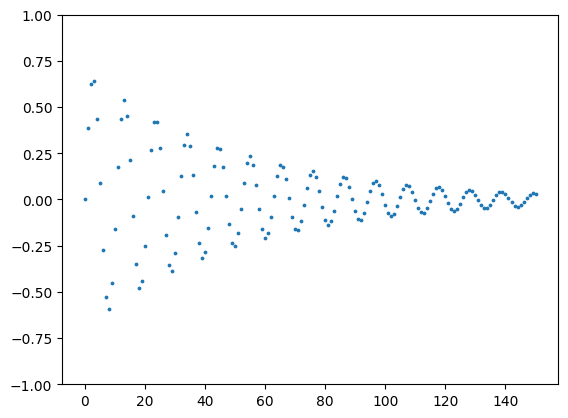

In [10]:
damp = ((torch.tensor([np.sin(_*0.6)*np.exp(_*-0.02) for _ in range(151)])*0.7)).float()
dampInput = damp[:-51]
dampTarget = damp[1:len(dampInput)+1]

dampInput = dampInput.reshape([len(dampInput),1])
dampTarget = dampTarget.reshape([len(dampTarget),1])

dampInput_a = damp[:-1]
dampInput_a = dampInput_a.reshape([len(dampInput_a),1])

plt.scatter(range(len(damp)), damp, s=3)
plt.ylim(-1,1)
plt.show()

## Load

In [11]:
with open('bStateA.pickle', 'rb') as f:
    bStateA = pickle.load(f)

## Export

In [12]:
results = [np.array(range(1,151))]
results.append(np.array(damp.tolist()[1:]))
best_model = Sequence()
for bState in bStateA:
    best_model.load_state_dict(bState)
    bestPredict = best_model(dampInput, 50).detach()
    bp = np.array(bestPredict.tolist()).flatten()
    results.append(bp)

results = np.array(results)

In [8]:
import csv

resultsT = results.T
with open('results.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(resultsT)

## Example

In [9]:
bState = bStateA[0]

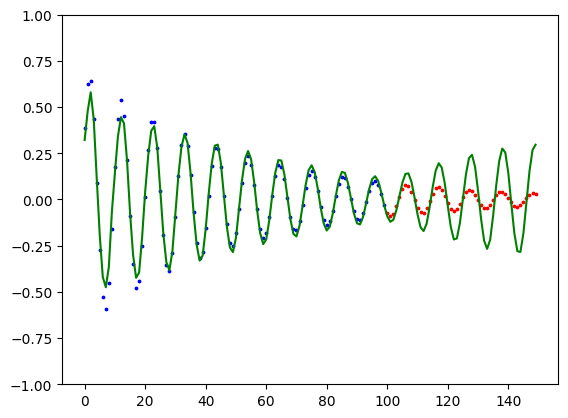

In [10]:
best_model = Sequence()
best_model.load_state_dict(bState)
bestPredict = best_model(dampInput, 50).detach()

bp = bestPredict.tolist()
ta = dampTarget.tolist()
tb = damp[len(dampInput)+1:].tolist()
plt.scatter(range(len(ta)), ta, c='b', s=3)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=3)
plt.plot(bp, c='g')
plt.ylim(-1,1)
plt.show()

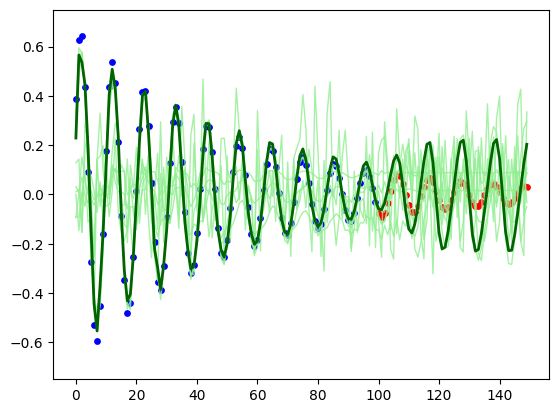

In [17]:
for run in results[2:]:
    plt.plot(run, color='lightgreen', alpha=0.8, linewidth=1)

plt.plot(results[9], color='darkgreen', linewidth=2, label='Median')

ta = dampTarget.tolist()
tb = damp[len(dampInput)+1:].tolist()
plt.scatter(range(len(ta)), ta, c='b', s=15)
plt.scatter(np.array(range(len(tb)))+len(ta), tb, c='r', s=15)

plt.ylim(-0.75,0.75)
plt.show()